# 🚢 Titanic – Pipeline de Preparación de Datos
## Machine Learning I · Estrategias para la preparación de datos y enfoques de problemas

---

Este notebook implementa un **pipeline completo de preparación de datos** sobre el famoso dataset del Titanic.  
El objetivo es dejar los datos listos para un futuro modelo de Machine Learning, siguiendo estos pasos:

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Carga y análisis exploratorio (EDA) |
| 2️⃣ | Identificación y tratamiento de valores faltantes |
| 3️⃣ | Transformación de variables categóricas (One-Hot Encoding) |
| 4️⃣ | Normalización de variables numéricas |
| 5️⃣ | Guardado del dataset limpio y archivos de metadatos |

> **Dataset:** `dataset.csv` — 891 pasajeros · 12 columnas originales  
> **Salida:** `dataset_cleaned.csv` + `scaler_params.json` + `schema.json`


---
## 📖 README — Configuración del entorno

Este notebook es **reutilizable en distintos entornos** sin modificar el código.  
Las rutas de entrada y salida se controlan mediante variables de entorno:

| Variable de entorno | Descripción | Valor por defecto |
|---------------------|-------------|-------------------|
| `TITANIC_INPUT` | Ruta al archivo CSV de entrada | `/workspace/dataset.csv` |
| `TITANIC_OUTPUT` | Ruta de salida para el CSV limpio | `/workspace/dataset_cleaned.csv` |

### Cómo sobreescribir las rutas

**Linux / macOS (terminal):**
```bash
export TITANIC_INPUT=/mi/ruta/dataset.csv
export TITANIC_OUTPUT=/mi/ruta/dataset_cleaned.csv
jupyter notebook cleaning.ipynb
```

**Windows (PowerShell):**
```powershell
$env:TITANIC_INPUT= "C:\mi\ruta\dataset.csv"
$env:TITANIC_OUTPUT = "C:\mi\ruta\dataset_cleaned.csv"
jupyter notebook cleaning.ipynb
```

**Dentro de otro notebook o script Python:**
```python
import os
os.environ["TITANIC_INPUT"]  = "/mi/ruta/dataset.csv"
os.environ["TITANIC_OUTPUT"] = "/mi/ruta/dataset_cleaned.csv"
```


## 0. Importación de librerías y configuración

Utilizamos exclusivamente `pandas` para la manipulación de datos y `matplotlib` / `seaborn` para las visualizaciones del EDA.

Las rutas de entrada y salida se parametrizan mediante **variables de entorno**, lo que hace el notebook reutilizable en distintos entornos sin modificar el código. Si las variables no están definidas, se usan las rutas por defecto.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

# ── Configuración de rutas ──────────────────────────────────────────────────
# Se pueden sobreescribir definiendo las variables de entorno antes de ejecutar:
#   export TITANIC_INPUT=/ruta/dataset.csv
#   export TITANIC_OUTPUT=/ruta/dataset_cleaned.csv
INPUT_PATH  = os.getenv("TITANIC_INPUT",  "workspace/dataset.csv")
OUTPUT_PATH = os.getenv("TITANIC_OUTPUT", "workspace/dataset_cleaned.csv")

print(f"📂 Input:  {INPUT_PATH}")
print(f"📂 Output: {OUTPUT_PATH}")
print("\n✅ Librerías cargadas correctamente")

📂 Input:  workspace/dataset.csv
📂 Output: workspace/dataset_cleaned.csv

✅ Librerías cargadas correctamente


---
## 1. Análisis Exploratorio de Datos (EDA)

### 1.1 Carga del dataset


In [2]:
df = pd.read_csv(INPUT_PATH)

print(f"📐 Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")


📐 Dimensiones del dataset: 891 filas × 12 columnas


### 1.2 Primeras filas del dataset (`df.head()`)

Visualizamos las 5 primeras filas para entender la estructura y contenido de cada columna.


In [3]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1.3 Información general del dataset (`df.info()`)

Inspeccionamos los tipos de dato de cada columna y el número de valores no nulos.


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### 1.4 Resumen estadístico

Estadísticas descriptivas de las columnas numéricas.


In [5]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 1.5 Identificación de valores faltantes — tabla combinada

Combinamos `df.dtypes` con el conteo de nulos y su porcentaje en una única tabla.  
Esto documenta de forma completa la **planificación de la imputación**: tipo de dato, magnitud del problema y estrategia elegida.

Usamos **indexación booleana directa** `df[condición]`, la forma más idiomática en pandas para filtrar filas.

> **Alternativas equivalentes** (solo informativo):
> - `.loc` — recomendado cuando se van a modificar valores: `missing_df.loc[missing_df["Nulos"] > 0]`
> - `.query()` — requiere backticks con nombres de columna con espacios: `` missing_df.query("`Nulos` > 0") ``


In [6]:
missing     = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)

# Tabla combinada: tipo de dato + nulos + porcentaje + estrategia
estrategias = {
    "Age":      "Mediana (numérico, distribución asimétrica)",
    "Cabin":    "Cadena 'Unknown' (~77% nulos, no inferible) + indicador binario",
    "Embarked": "Moda (texto, solo 2 nulos)",
}

missing_df = pd.DataFrame({
    "Tipo de dato":       df.dtypes,
    "Nulos":              missing,
    "Porcentaje (%)":     missing_pct,
    "Estrategia":         pd.Series(estrategias),
})
missing_df = missing_df[missing_df["Nulos"] > 0].sort_values("Porcentaje (%)", ascending=False)

print("📋 Columnas con valores faltantes:")
print(missing_df.to_string())


📋 Columnas con valores faltantes:
         Tipo de dato  Nulos  Porcentaje (%)                                                       Estrategia
Cabin             str    687           77.10  Cadena 'Unknown' (~77% nulos, no inferible) + indicador binario
Age           float64    177           19.87                      Mediana (numérico, distribución asimétrica)
Embarked          str      2            0.22                                       Moda (texto, solo 2 nulos)


### 1.6 Visualización de distribuciones y boxplots

Exploramos la distribución de las variables numéricas principales y detectamos outliers  
mediante **boxplots por clase de pasajero y por supervivencia**.


C:\Users\macdu\AppData\Local\Temp\ipykernel_3916\2586661883.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Pclass", y="Age", palette="Set2", ax=axes[1,0])
C:\Users\macdu\AppData\Local\Temp\ipykernel_3916\2586661883.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Survived", y="Fare", palette=["#e74c3c","#2ecc71"], ax=axes[1,1])
C:\Users\macdu\AppData\Local\Temp\ipykernel_3916\2586661883.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(["No sobrevivió", "Sobrevivió"])
C:\Users\macdu\AppData\Local\Temp\ipykernel_3916\2586661883.py:29: FutureWarni

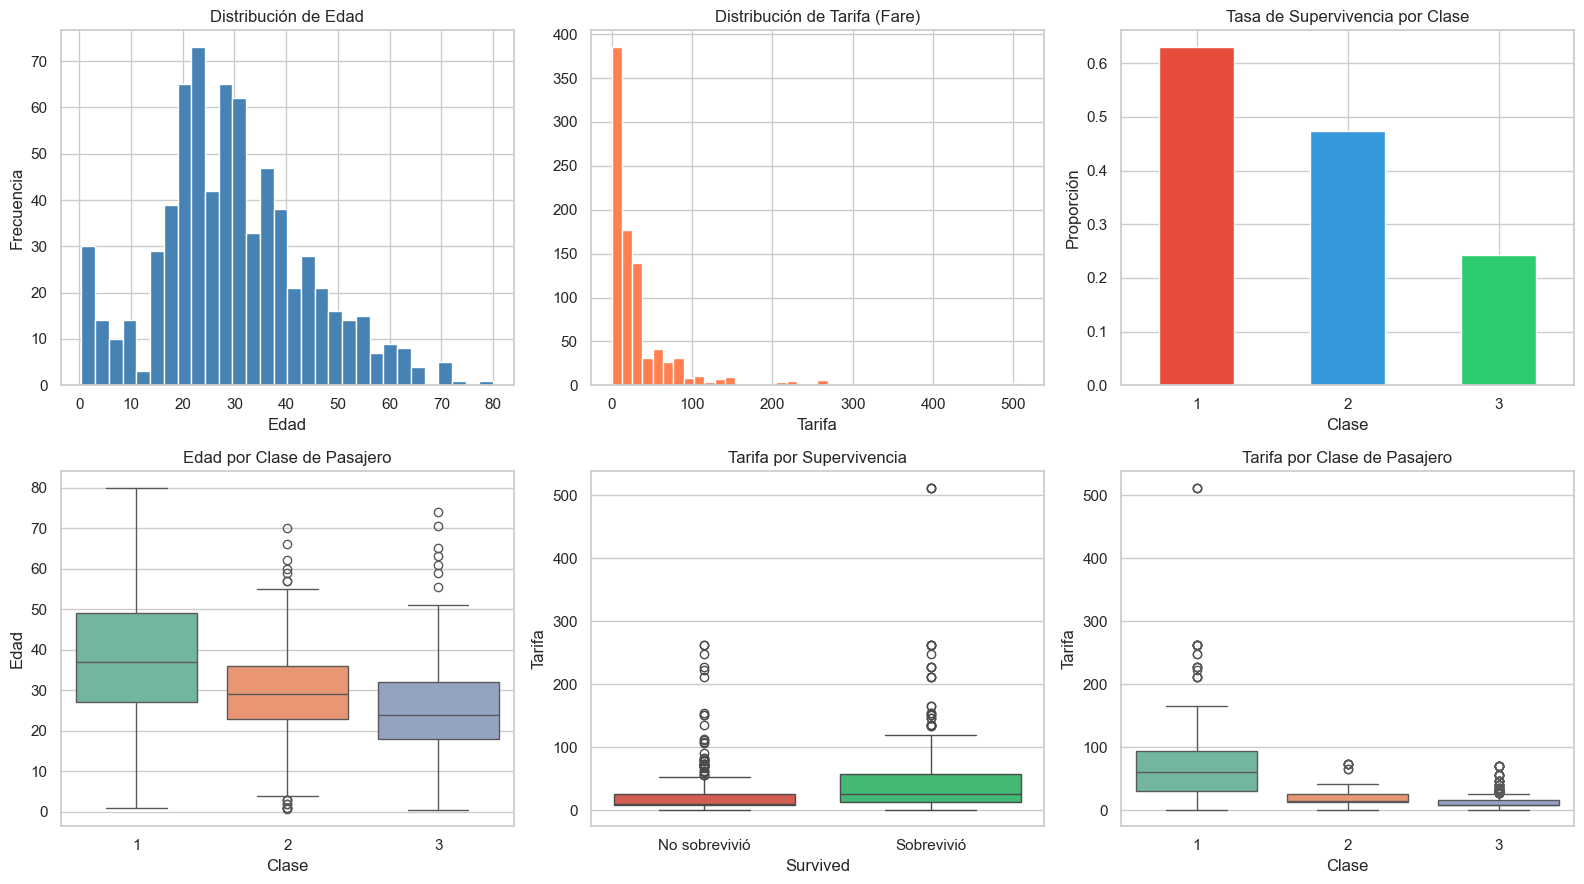

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Fila 1 — Histogramas
df["Age"].dropna().hist(ax=axes[0,0], bins=30, color="steelblue", edgecolor="white")
axes[0,0].set_title("Distribución de Edad")
axes[0,0].set_xlabel("Edad"); axes[0,0].set_ylabel("Frecuencia")

df["Fare"].hist(ax=axes[0,1], bins=40, color="coral", edgecolor="white")
axes[0,1].set_title("Distribución de Tarifa (Fare)")
axes[0,1].set_xlabel("Tarifa")

df.groupby("Pclass")["Survived"].mean().plot(
    kind="bar", ax=axes[0,2], color=["#e74c3c","#3498db","#2ecc71"], edgecolor="white"
)
axes[0,2].set_title("Tasa de Supervivencia por Clase")
axes[0,2].set_xlabel("Clase"); axes[0,2].set_ylabel("Proporción")
axes[0,2].tick_params(axis='x', rotation=0)

# Fila 2 — Boxplots (outliers y diferencias por grupo)
sns.boxplot(data=df, x="Pclass", y="Age", palette="Set2", ax=axes[1,0])
axes[1,0].set_title("Edad por Clase de Pasajero")
axes[1,0].set_xlabel("Clase"); axes[1,0].set_ylabel("Edad")

sns.boxplot(data=df, x="Survived", y="Fare", palette=["#e74c3c","#2ecc71"], ax=axes[1,1])
axes[1,1].set_title("Tarifa por Supervivencia")
axes[1,1].set_xticklabels(["No sobrevivió", "Sobrevivió"])
axes[1,1].set_ylabel("Tarifa")

sns.boxplot(data=df, x="Pclass", y="Fare", palette="Set2", ax=axes[1,2])
axes[1,2].set_title("Tarifa por Clase de Pasajero")
axes[1,2].set_xlabel("Clase"); axes[1,2].set_ylabel("Tarifa")

plt.tight_layout()
plt.show()


**Observaciones de los boxplots:**
- **Edad por clase:** los pasajeros de 1ª clase tienden a ser mayores; hay outliers en todas las clases.
- **Tarifa por supervivencia:** los supervivientes pagaron tarifas significativamente más altas, con muchos outliers al alza.
- **Tarifa por clase:** la 1ª clase presenta una dispersión muy alta y numerosos outliers — justifica la necesidad de normalización.


### 1.7 Matriz de correlación

Correlaciones lineales entre variables numéricas y la variable objetivo `Survived`.


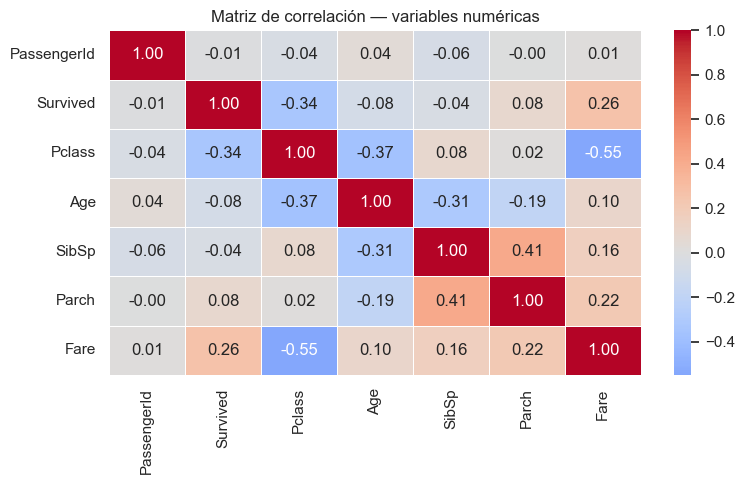


📊 Correlaciones con 'Survived' (ordenadas por valor absoluto):
  Pclass      : -0.338  (negativa)
  Fare        : +0.257  (positiva)
  Parch       : +0.082  (positiva)
  Age         : -0.077  (negativa)
  SibSp       : -0.035  (negativa)
  PassengerId : -0.005  (negativa)


In [8]:
plt.figure(figsize=(8, 5))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de correlación — variables numéricas")
plt.tight_layout()
plt.show()

# Correlaciones más relevantes con Survived
print("\n📊 Correlaciones con 'Survived' (ordenadas por valor absoluto):")
corr_survived = corr["Survived"].drop("Survived").sort_values(key=abs, ascending=False)
for col, val in corr_survived.items():
    direccion = "positiva" if val > 0 else "negativa"
    print(f"  {col:12s}: {val:+.3f}  ({direccion})")


**Correlaciones más relevantes con `Survived`:**

| Variable | Correlación | Interpretación |
|----------|-------------|----------------|
| `Fare` | positiva (~0.26) | Tarifas más altas → mayor probabilidad de supervivencia (clase alta) |
| `Pclass` | negativa (~-0.34) | Clases más bajas (número mayor) → menor supervivencia |
| `Age` | negativa (~-0.08) | Leve relación: pasajeros mayores sobrevivieron algo menos |
| `SibSp` / `Parch` | débil | Familia a bordo tiene relación débil con supervivencia |

> Estas correlaciones son **lineales**; relaciones no lineales pueden captarse con modelos más complejos.


---
## 2. Limpieza de Valores Faltantes

Trabajamos sobre una copia del DataFrame original.  
`df.copy()` crea un objeto **nuevo e independiente** en memoria — a diferencia de `df_clean = df`,
que solo crearía una segunda referencia al mismo objeto y cualquier modificación afectaría también al original.


In [9]:
df_clean = df.copy()


### 2.1 Variables numéricas — Imputación con la mediana

**`Age`**: la mediana es más robusta que la media ante valores extremos y distribuciones asimétricas.


In [10]:
age_median = df_clean["Age"].median()
print(f"📊 Mediana de Age: {age_median}")

df_clean["Age"] = df_clean["Age"].fillna(age_median)
print(f"✅ Nulos en Age tras imputación: {df_clean['Age'].isna().sum()}")


📊 Mediana de Age: 28.0
✅ Nulos en Age tras imputación: 0


### 2.2 Variables de texto — Imputación con moda o cadena fija


In [11]:
embarked_mode = df_clean["Embarked"].mode()[0]
print(f"📊 Moda de Embarked: '{embarked_mode}'")
df_clean["Embarked"] = df_clean["Embarked"].fillna(embarked_mode)

df_clean["Cabin"] = df_clean["Cabin"].fillna("Unknown")

print(f"✅ Nulos en Embarked: {df_clean['Embarked'].isna().sum()}")
print(f"✅ Nulos en Cabin:    {df_clean['Cabin'].isna().sum()}")


📊 Moda de Embarked: 'S'
✅ Nulos en Embarked: 0
✅ Nulos en Cabin:    0


### 2.3 Verificación columna a columna

En lugar de un único `assert` global, verificamos y reportamos **columna a columna**.  
Esto facilita el trazado de problemas en pipelines más grandes: si falla algo, sabemos exactamente dónde.


In [12]:
print("🔍 Verificación de nulos por columna tras limpieza:\n")

hay_problemas = False
for col in df_clean.columns:
    nulos = df_clean[col].isna().sum()
    estado = "✅" if nulos == 0 else "❌"
    if nulos > 0:
        hay_problemas = True
    print(f"  {estado} {col:15s}: {nulos} nulos")

print()
if hay_problemas:
    raise ValueError("⚠️ Se encontraron columnas con valores faltantes — revisar pipeline")
else:
    print("✅ Todas las columnas sin valores faltantes — pipeline OK")


🔍 Verificación de nulos por columna tras limpieza:

  ✅ PassengerId    : 0 nulos
  ✅ Survived       : 0 nulos
  ✅ Pclass         : 0 nulos
  ✅ Name           : 0 nulos
  ✅ Sex            : 0 nulos
  ✅ Age            : 0 nulos
  ✅ SibSp          : 0 nulos
  ✅ Parch          : 0 nulos
  ✅ Ticket         : 0 nulos
  ✅ Fare           : 0 nulos
  ✅ Cabin          : 0 nulos
  ✅ Embarked       : 0 nulos

✅ Todas las columnas sin valores faltantes — pipeline OK


### 3.1 Eliminación de columnas no útiles para el modelado

Antes de codificar, eliminamos columnas que no aportan información predictiva.  
La decisión se justifica cuantitativamente midiendo la **cardinalidad** de cada columna:

| Columna | Valores únicos | Motivo de eliminación |
|---------|---------------|----------------------|
| `PassengerId` | 891 | Identificador único — sin valor predictivo |
| `Name` | 891 | Texto libre — alta cardinalidad, no normalizable directamente |
| `Ticket` | 681 | Código sin patrón uniforme aprovechable |
| `Cabin` | 147 (+Unknown) | ~77% valores desconocidos — se conserva indicador binario `Cabin_known` |


In [13]:
# Justificación cuantitativa de la eliminación
columnas_a_eliminar = ["PassengerId", "Name", "Ticket", "Cabin"]

for col in columnas_a_eliminar:
    nunique = df_clean[col].nunique()
    print(f"  {col:15s}: {nunique} valores únicos")


  PassengerId    : 891 valores únicos
  Name           : 891 valores únicos
  Ticket         : 681 valores únicos
  Cabin          : 148 valores únicos


In [14]:
# Indicador binario de cabina conocida antes de eliminar Cabin
df_clean["Cabin_known"] = (df["Cabin"].notna()).astype(int)

print(f"📊 Supervivencia con cabina conocida:    {df_clean[df_clean['Cabin_known']==1]['Survived'].mean():.2f}")
print(f"📊 Supervivencia con cabina desconocida: {df_clean[df_clean['Cabin_known']==0]['Survived'].mean():.2f}")
print("→ Diferencia relevante — se conserva como indicador binario 'Cabin_known'")


📊 Supervivencia con cabina conocida:    0.67
📊 Supervivencia con cabina desconocida: 0.30
→ Diferencia relevante — se conserva como indicador binario 'Cabin_known'


In [15]:
df_clean = df_clean.drop(columns=columnas_a_eliminar)

print(f"📐 Columnas tras eliminación: {list(df_clean.columns)}")


📐 Columnas tras eliminación: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Cabin_known']


### 3.2 One-Hot Encoding — detección automática de columnas categóricas

En lugar de hardcodear los nombres, **detectamos automáticamente** las columnas de tipo `object`.  
Esto hace el pipeline reutilizable si se agregan nuevas columnas categóricas en el futuro.


In [16]:
# Detección automática de columnas categóricas
columnas_categoricas = df_clean.select_dtypes(include="object").columns.tolist()
print(f"🔤 Columnas categóricas detectadas automáticamente: {columnas_categoricas}")

df_clean = pd.get_dummies(df_clean, columns=columnas_categoricas, drop_first=True, dtype=int)

print(f"\n✅ Columnas tras One-Hot Encoding:")
print(df_clean.columns.tolist())


🔤 Columnas categóricas detectadas automáticamente: ['Sex', 'Embarked']

✅ Columnas tras One-Hot Encoding:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin_known', 'Sex_male', 'Embarked_Q', 'Embarked_S']


C:\Users\macdu\AppData\Local\Temp\ipykernel_3916\3881842933.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df_clean.select_dtypes(include="object").columns.tolist()


### 3.3 Normalización Min-Max de variables numéricas continuas

Aplicamos **normalización Min-Max** a `Age` y `Fare` para escalarlas al rango [0, 1].  
Las variables discretas/ordinales (`Survived`, `Pclass`, `SibSp`, `Parch`) no se normalizan.


In [17]:
columnas_normalizar = ["Age", "Fare"]

for col in columnas_normalizar:
    col_min = df_clean[col].min()
    col_max = df_clean[col].max()
    df_clean[col] = (df_clean[col] - col_min) / (col_max - col_min)
    print(f"📊 {col}: min={df_clean[col].min():.4f}, max={df_clean[col].max():.4f}")

print("\n✅ Normalización Min-Max aplicada a:", columnas_normalizar)


📊 Age: min=0.0000, max=1.0000
📊 Fare: min=0.0000, max=1.0000

✅ Normalización Min-Max aplicada a: ['Age', 'Fare']


---
## 4. Inspección del Dataset Final


In [18]:
print(f"📐 Dimensiones finales: {df_clean.shape[0]} filas × {df_clean.shape[1]} columnas")
print()
df_clean.head()


📐 Dimensiones finales: 891 filas × 10 columnas



,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin_known,Sex_male,Embarked_Q,Embarked_S
0,0,3,0.271174,1,0,0.014151,0,1,0,1
1,1,1,0.472229,1,0,0.139136,1,0,0,0
2,1,3,0.321438,0,0,0.015469,0,0,0,1
3,1,1,0.434531,1,0,0.103644,1,0,0,1
4,0,3,0.434531,0,0,0.015713,0,1,0,1


In [19]:
df_clean.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   Cabin_known  891 non-null    int64  
 7   Sex_male     891 non-null    int64  
 8   Embarked_Q   891 non-null    int64  
 9   Embarked_S   891 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 69.7 KB


In [20]:
df_clean.describe().round(4)


,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin_known,Sex_male,Embarked_Q,Embarked_S
count,891.0000,891.0000,891.0000,891.0000,891.0000,891.0000,891.0000,891.0000,891.0000,891.0000
mean,0.3838,2.3086,0.3637,0.5230,0.3816,0.0629,0.2290,0.6476,0.0864,0.7250
std,0.4866,0.8361,0.1636,1.1027,0.8061,0.0970,0.4204,0.4780,0.2811,0.4468
min,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,2.0000,0.2712,0.0000,0.0000,0.0154,0.0000,0.0000,0.0000,0.0000
50%,0.0000,3.0000,0.3466,0.0000,0.0000,0.0282,0.0000,1.0000,0.0000,1.0000
75%,1.0000,3.0000,0.4345,1.0000,0.0000,0.0605,0.0000,1.0000,0.0000,1.0000
max,1.0000,3.0000,1.0000,8.0000,6.0000,1.0000,1.0000,1.0000,1.0000,1.0000


---
## 5. Guardado del Dataset Limpio

Exportamos el DataFrame procesado y verificamos que el archivo se ha creado correctamente.


In [21]:
df_clean.to_csv(OUTPUT_PATH, index=False)

assert os.path.exists(OUTPUT_PATH), "⚠️ El archivo no se ha guardado correctamente"

print(f"💾 Dataset guardado en:  {OUTPUT_PATH}")
print(f"📐 Shape:                {df_clean.shape}")
print(f"📦 Tamaño del archivo:   {os.path.getsize(OUTPUT_PATH) / 1024:.1f} KB")
print(f"🔍 Valores nulos:        {df_clean.isna().sum().sum()}")
print("\n✅ Pipeline de preparación de datos completado con éxito.")


💾 Dataset guardado en:  workspace/dataset_cleaned.csv
📐 Shape:                (891, 10)
📦 Tamaño del archivo:   49.3 KB
🔍 Valores nulos:        0

✅ Pipeline de preparación de datos completado con éxito.


---
## 📝 Resumen del Pipeline

| Paso | Acción | Resultado |
|------|--------|-----------|
| EDA | `head`, `info`, estadísticas, histogramas, boxplots, heatmap con anotaciones | Comprensión del dataset |
| Valores faltantes | `Age` → mediana · `Embarked` → moda · `Cabin` → `'Unknown'` | 866 nulos → 0 |
| Verificación | Columna a columna con reporte detallado | Trazabilidad de errores |
| Indicador binario | `Cabin_known` (1 si cabina conocida, 0 si no) | Nueva feature añadida |
| Eliminación columnas | `PassengerId`, `Name`, `Ticket`, `Cabin` (justificado por cardinalidad) | 12 → 9 columnas base |
| One-Hot Encoding | Detección automática de columnas `object` | Pipeline reutilizable |
| Normalización Min-Max | `Age`, `Fare` → [0, 1] | Rango [0, 1] |
| **Output** | `dataset_cleaned.csv` | **891 filas · listo para modelado** |
